# VNSP — Exploratory Data Analysis
Tái hiện các hình trong bài báo Li et al. (2026) với dữ liệu VCB & VIC (HOSE).

| Task | Figures |
|------|---------|
| 2.1 | Fig. 2 — Deviation scatter |
| 2.2 | Fig. 6 — db4 wavelet functions · Fig. 7/8 — Approx/Detail coefficients |
| 2.3 | Fig. 3/4 — Feature distributions before/after scaling |
| 2.4 | Fig. 10 — Correlation matrix |

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path().resolve().parent          # notebooks/ → project root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from app.config import PATHS, FOLDS, CORRELATION_THRESHOLD
from app.services.data_service import load_stock_data
from app.services.preprocessing import (
    add_deviation_feature,
    FeatureScaler,
    select_features_by_correlation,
    plot_feature_distributions,
    plot_correlation_matrix,
)
from app.services.wavelet_service import (
    decompose_all_features,
    plot_wavelet_coefficients,
    visualize_wavelet_functions,
)

FIGURES_DIR   = ROOT / PATHS['figures']
PROCESSED_DIR = ROOT / PATHS['processed']
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print(f'ROOT:          {ROOT}')
print(f'FIGURES_DIR:   {FIGURES_DIR}')
print(f'PROCESSED_DIR: {PROCESSED_DIR}')

ROOT:          /Users/sura/pros/vns-sp
FIGURES_DIR:   /Users/sura/pros/vns-sp/data/figures
PROCESSED_DIR: /Users/sura/pros/vns-sp/data/processed


In [2]:
# ── Load raw data + Deviation (shared for all sections) ────────────────────────
df_vcb_raw = load_stock_data('VCB')
df_vic_raw = load_stock_data('VIC')

df_vcb = add_deviation_feature(df_vcb_raw)
df_vic = add_deviation_feature(df_vic_raw)

print('VCB:', df_vcb.shape, '| cols:', list(df_vcb.columns))
print('VIC:', df_vic.shape, '| cols:', list(df_vic.columns))

01:07:15 | INFO | [VCB] CSV tồn tại — load từ data/raw/VCB_raw.csv (bỏ qua API).
01:07:15 | INFO | [VCB] Clip date range: 3,394 → 3,246 rows (2012-01-01 → 2024-12-31).
01:07:15 | WARNING | [VCB] ⚠️ 13 khoảng trống >7 ngày:
  • 2012-01-30: gap 10 ngày
  • 2013-02-18: gap 10 ngày
  • 2014-02-06: gap 10 ngày
  • 2015-02-24: gap 11 ngày
  • 2016-02-15: gap 10 ngày
  • 2017-02-02: gap 8 ngày
  • 2018-02-21: gap 8 ngày
  • 2019-02-11: gap 10 ngày
  • 2020-01-30: gap 8 ngày
  • 2021-02-17: gap 8 ngày
  • 2022-02-07: gap 10 ngày
  • 2023-01-27: gap 8 ngày
  • 2024-02-15: gap 8 ngày
01:07:15 | INFO | [VCB] Validation OK — 3,246 rows, 0 NaN.
01:07:15 | INFO | [VIC] CSV tồn tại — load từ data/raw/VIC_raw.csv (bỏ qua API).
01:07:15 | INFO | [VIC] Clip date range: 3,394 → 3,246 rows (2012-01-01 → 2024-12-31).
01:07:15 | WARNING | [VIC] ⚠️ 13 khoảng trống >7 ngày:
  • 2012-01-30: gap 10 ngày
  • 2013-02-18: gap 10 ngày
  • 2014-02-06: gap 10 ngày
  • 2015-02-24: gap 11 ngày
  • 2016-02-15: gap 10 ng

VCB: (3246, 6) | cols: ['Open', 'High', 'Low', 'Close', 'Volume', 'Deviation']
VIC: (3246, 6) | cols: ['Open', 'High', 'Low', 'Close', 'Volume', 'Deviation']


---
## Section 1 — Fig. 2: Deviation Scatter (Task 2.1)

Tái hiện Fig. 2 — Deviation Changes as Stock Price Increases.

In [3]:
def plot_deviation_scatter(df, ticker, currency='VND', save=True):
    """Scatter: Close Price (X) vs Deviation (Y). Tái hiện Fig. 2."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(df['Close'], df['Deviation'],
               color='steelblue', alpha=0.4, s=8, linewidths=0)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.7)
    if currency == 'VND':
        for thr in [50, -50]:
            ax.axhline(thr, color='tomato', linewidth=0.9, linestyle=':', alpha=0.8,
                       label=f'{thr:+d} VND threshold')
        ax.legend(fontsize=9, loc='upper left')
    ax.set_title(f'{ticker}-Deviation Changes as Stock Price Increases',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'Close Price ({currency})', fontsize=11)
    ax.set_ylabel(f'Deviation ({currency})', fontsize=11)
    n = len(df)
    n_large = (df['Deviation'].abs() > 50).sum()
    ax.text(0.98, 0.97,
        f'n={n:,} trading days\nMean:{df["Deviation"].mean():.1f}  Std:{df["Deviation"].std():.1f}\n|Dev|>50: {n_large:,} ({100*n_large/n:.1f}%)',
        transform=ax.transAxes, fontsize=8, va='top', ha='right',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='gray'))
    plt.tight_layout()
    if save:
        p = FIGURES_DIR / f'{ticker}_deviation_scatter_{currency}.png'
        fig.savefig(p, dpi=150, bbox_inches='tight')
        print(f'Saved: {p}')
    plt.show()
    plt.close(fig)

Saved: /Users/sura/pros/vns-sp/data/figures/VCB_deviation_scatter_VND.png


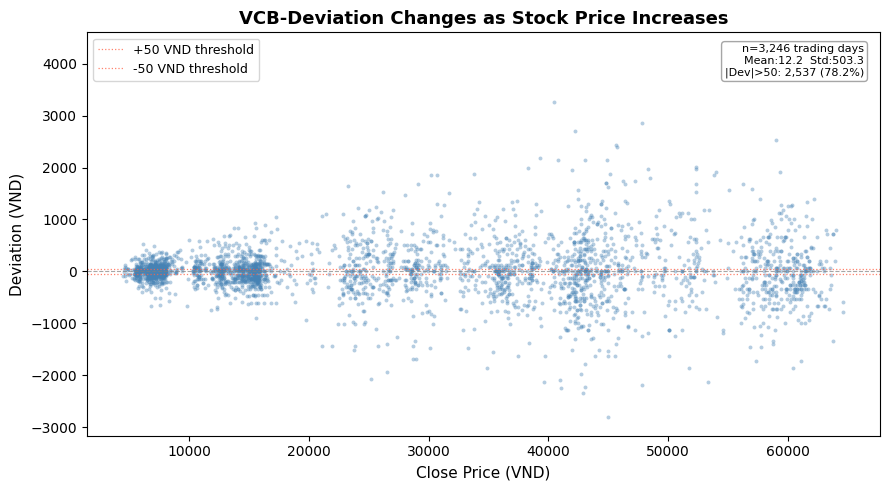

In [4]:
plot_deviation_scatter(df_vcb, 'VCB', currency='VND')

Saved: /Users/sura/pros/vns-sp/data/figures/VIC_deviation_scatter_VND.png


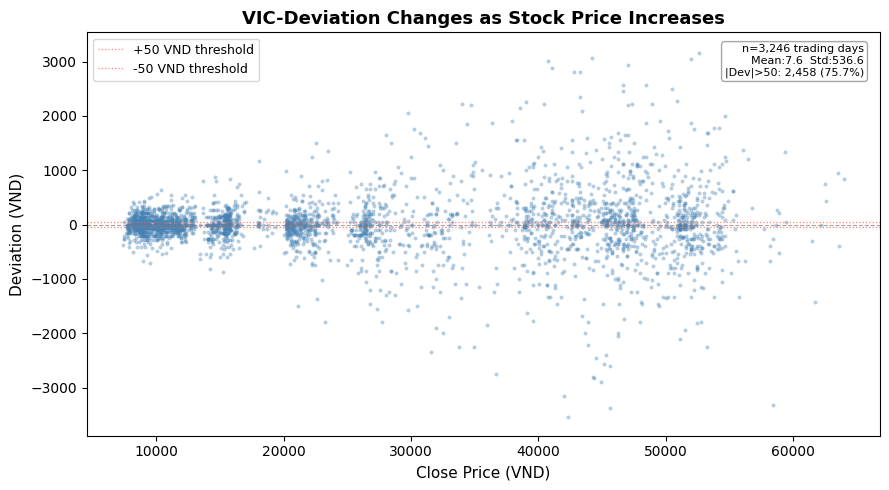

In [5]:
plot_deviation_scatter(df_vic, 'VIC', currency='VND')

In [6]:
# Optional: USD versions (cần USDVND.csv)
try:
    from app.services.data_service import prepare_both_currencies
    from app.services.preprocessing import add_deviation_feature as _add_dev
    for ticker in ['VCB', 'VIC']:
        usd_df = _add_dev(prepare_both_currencies(ticker)['USD'])
        plot_deviation_scatter(usd_df, ticker, currency='USD')
except FileNotFoundError as e:
    print(f'Skip USD: {e}')

01:07:35 | INFO | [VCB] CSV tồn tại — load từ data/raw/VCB_raw.csv (bỏ qua API).
01:07:35 | INFO | [VCB] Clip date range: 3,394 → 3,246 rows (2012-01-01 → 2024-12-31).
01:07:35 | WARNING | [VCB] ⚠️ 13 khoảng trống >7 ngày:
  • 2012-01-30: gap 10 ngày
  • 2013-02-18: gap 10 ngày
  • 2014-02-06: gap 10 ngày
  • 2015-02-24: gap 11 ngày
  • 2016-02-15: gap 10 ngày
  • 2017-02-02: gap 8 ngày
  • 2018-02-21: gap 8 ngày
  • 2019-02-11: gap 10 ngày
  • 2020-01-30: gap 8 ngày
  • 2021-02-17: gap 8 ngày
  • 2022-02-07: gap 10 ngày
  • 2023-01-27: gap 8 ngày
  • 2024-02-15: gap 8 ngày
01:07:35 | INFO | [VCB] Validation OK — 3,246 rows, 0 NaN.


Skip USD: Không tìm thấy file tỷ giá: data/raw/USDVND.csv
Hướng dẫn tải thủ công:
  1. Truy cập: https://www.investing.com/currencies/usd-vnd-historical-data
  2. Đăng nhập (tài khoản free)
  3. Chọn date range: 01/01/2012 → 31/12/2024
  4. Nhấn 'Download' (biểu tượng mũi tên xuống)
  5. Đổi tên file thành 'USDVND.csv' → đặt vào data/raw/USDVND.csv


---
## Section 2 — Wavelet Analysis (Task 2.2)

**Fig. 6** — db4 Wavelet & Scaling Functions  
**Fig. 7** — Approximation + Detail Coefficients — VIC (≈ Tesla in paper)  
**Fig. 8** — Approximation + Detail Coefficients — VCB (≈ Apple in paper)

In [7]:
# Fig. 6 — db4 wavelet ψ(t) and scaling function φ(t)
visualize_wavelet_functions(
    save_path=FIGURES_DIR / 'fig6_db4_wavelet_functions.png'
)
print('Fig. 6 saved')

01:08:22 | INFO | [plot] db4 wavelet functions → /Users/sura/pros/vns-sp/data/figures/fig6_db4_wavelet_functions.png


Fig. 6 saved


In [8]:
# SWT db4 level-1 decomposition: 5 features → 10 coefficients + Close target
df_vcb_wav = decompose_all_features(df_vcb)
df_vic_wav = decompose_all_features(df_vic)

print('Columns after SWT:')
print(list(df_vcb_wav.columns))
print(f'VCB: {df_vcb_wav.shape} | VIC: {df_vic_wav.shape}')

01:08:29 | INFO | [SWT] Bắt đầu decompose | wavelet=db4 | level=1 | features=['Open', 'High', 'Low', 'Volume', 'Deviation'] | rows=3,246
01:08:29 | INFO | [SWT] Open         → Approx std=25773.7755  Detail std=675.794953
01:08:29 | INFO | [SWT] High         → Approx std=26005.3751  Detail std=634.931585
01:08:29 | INFO | [SWT] Low          → Approx std=25538.4080  Detail std=635.952911
01:08:29 | INFO | [SWT] Volume       → Approx std=1024295.8407  Detail std=481932.481657
01:08:29 | INFO | [SWT] Deviation    → Approx std=497.5714  Detail std=508.825030
01:08:29 | INFO | [SWT] Decomposition hoàn tất | Input features: 5 | Output: 10 features + Close target | Shape: (3246, 11)
01:08:29 | INFO | [SWT] Bắt đầu decompose | wavelet=db4 | level=1 | features=['Open', 'High', 'Low', 'Volume', 'Deviation'] | rows=3,246
01:08:29 | INFO | [SWT] Open         → Approx std=22537.0602  Detail std=385.473967
01:08:29 | INFO | [SWT] High         → Approx std=22794.8026  Detail std=310.636046
01:08:29 | 

Columns after SWT:
['Open_Approx', 'Open_Detail', 'High_Approx', 'High_Detail', 'Low_Approx', 'Low_Detail', 'Volume_Approx', 'Volume_Detail', 'Deviation_Approx', 'Deviation_Detail', 'Close']
VCB: (3246, 11) | VIC: (3246, 11)


In [9]:
# Fig. 7 — VIC Approximation & Detail Coefficients
plot_wavelet_coefficients(
    df_vic_wav, ticker='VIC',
    save_path=FIGURES_DIR / 'fig7_VIC_wavelet_coefficients.png'
)
print('Fig. 7 (VIC) saved')

01:08:34 | INFO | [plot] Wavelet coefficients → /Users/sura/pros/vns-sp/data/figures/fig7_VIC_wavelet_coefficients.png


Fig. 7 (VIC) saved


In [10]:
# Fig. 8 — VCB Approximation & Detail Coefficients
plot_wavelet_coefficients(
    df_vcb_wav, ticker='VCB',
    save_path=FIGURES_DIR / 'fig8_VCB_wavelet_coefficients.png'
)
print('Fig. 8 (VCB) saved')

01:09:37 | INFO | [plot] Wavelet coefficients → /Users/sura/pros/vns-sp/data/figures/fig8_VCB_wavelet_coefficients.png


Fig. 8 (VCB) saved


---
## Section 3 — Feature Scaling (Task 2.3)

**Fig. 3** — Raw (before scaling): bimodal distribution do giá cổ phiếu tăng theo thời gian  
**Fig. 4** — After scaling: phân phối được chuẩn hóa

Lưu ý: Để tái hiện đúng bài báo, dùng toàn bộ dataset để visualize distribution.

In [11]:
# Scale wavelet features cho visualization
# (trong training pipeline: fit scaler CHỈ trên train fold)
for ticker, df_wav in [('VCB', df_vcb_wav), ('VIC', df_vic_wav)]:
    scaler_viz = FeatureScaler()
    df_scaled = scaler_viz.fit_transform(df_wav)

    plot_feature_distributions(
        df_before=df_wav,
        df_after=df_scaled,
        ticker=ticker,
        save_path=FIGURES_DIR / f'fig3_4_{ticker}_distributions.png',
        max_features=6,
    )
    print(f'Fig. 3/4 ({ticker}) saved')

01:10:13 | INFO | [FeatureScaler] fit() xong | 10 scalers fitted | Columns không scale: ['Open_Approx']
01:10:14 | INFO | [plot] Feature distributions → /Users/sura/pros/vns-sp/data/figures/fig3_4_VCB_distributions.png
01:10:14 | INFO | [FeatureScaler] fit() xong | 10 scalers fitted | Columns không scale: ['Open_Approx']


Fig. 3/4 (VCB) saved


01:10:15 | INFO | [plot] Feature distributions → /Users/sura/pros/vns-sp/data/figures/fig3_4_VIC_distributions.png


Fig. 3/4 (VIC) saved


---
## Section 4 — Feature Selection by Correlation (Task 2.4)

**Fig. 10** — Correlation matrix heatmap trước và sau feature selection  

Dùng Fold 1 training data (2012–2017) để tính correlation (chống data leakage).

In [12]:
# Fold 1 train period: 2012-01-01 → 2017-12-31
fold1_train_end = FOLDS[0]['train_end']   # '2017-12-31'
print(f'Fold 1 train through: {fold1_train_end}')
print(f'Correlation threshold: {CORRELATION_THRESHOLD}')

Fold 1 train through: 2017-12-31
Correlation threshold: 0.95


In [13]:
for ticker, df_wav in [('VCB', df_vcb_wav), ('VIC', df_vic_wav)]:
    # Chỉ dùng training data
    df_train = df_wav[df_wav.index <= fold1_train_end]

    # Scale on train only
    scaler_fold = FeatureScaler()
    df_train_scaled = scaler_fold.fit_transform(df_train)

    # Fig. 10a — Correlation matrix BEFORE selection
    plot_correlation_matrix(
        df_train_scaled, ticker=ticker,
        save_path=FIGURES_DIR / f'fig10_{ticker}_correlation_before.png',
    )

    # Feature selection
    df_selected, dropped = select_features_by_correlation(
        df_train_scaled, threshold=CORRELATION_THRESHOLD
    )

    print(f'\n{ticker} feature selection (threshold={CORRELATION_THRESHOLD}):')
    print(f'  Dropped ({len(dropped)}): {dropped}')
    kept = [c for c in df_selected.columns if c != 'Close']
    print(f'  Kept    ({len(kept)}): {kept}')

    # Fig. 10b — Correlation matrix AFTER selection
    if len(kept) >= 2:
        plot_correlation_matrix(
            df_selected, ticker=f'{ticker}_selected',
            save_path=FIGURES_DIR / f'fig10_{ticker}_correlation_after.png',
        )
    print(f'  Fig. 10 ({ticker}) saved')

01:10:45 | INFO | [FeatureScaler] fit() xong | 10 scalers fitted | Columns không scale: ['Open_Approx']
01:10:45 | INFO | [plot] Correlation matrix → /Users/sura/pros/vns-sp/data/figures/fig10_VCB_correlation_before.png
01:10:45 | INFO | [CorrelationSelect] threshold=0.95 | Input: 10 features | Dropped (2): ['Low_Approx', 'Open_Approx'] | Kept (8): ['Open_Detail', 'High_Approx', 'High_Detail', 'Low_Detail', 'Volume_Approx', 'Volume_Detail', 'Deviation_Approx', 'Deviation_Detail']
01:10:45 | INFO | [plot] Correlation matrix → /Users/sura/pros/vns-sp/data/figures/fig10_VCB_correlation_after.png
01:10:45 | INFO | [FeatureScaler] fit() xong | 10 scalers fitted | Columns không scale: ['Open_Approx']



VCB feature selection (threshold=0.95):
  Dropped (2): ['Low_Approx', 'Open_Approx']
  Kept    (8): ['Open_Detail', 'High_Approx', 'High_Detail', 'Low_Detail', 'Volume_Approx', 'Volume_Detail', 'Deviation_Approx', 'Deviation_Detail']
  Fig. 10 (VCB) saved


01:10:45 | INFO | [plot] Correlation matrix → /Users/sura/pros/vns-sp/data/figures/fig10_VIC_correlation_before.png
01:10:45 | INFO | [CorrelationSelect] threshold=0.95 | Input: 10 features | Dropped (2): ['Low_Approx', 'Open_Approx'] | Kept (8): ['Open_Detail', 'High_Approx', 'High_Detail', 'Low_Detail', 'Volume_Approx', 'Volume_Detail', 'Deviation_Approx', 'Deviation_Detail']
01:10:45 | INFO | [plot] Correlation matrix → /Users/sura/pros/vns-sp/data/figures/fig10_VIC_correlation_after.png



VIC feature selection (threshold=0.95):
  Dropped (2): ['Low_Approx', 'Open_Approx']
  Kept    (8): ['Open_Detail', 'High_Approx', 'High_Detail', 'Low_Detail', 'Volume_Approx', 'Volume_Detail', 'Deviation_Approx', 'Deviation_Detail']
  Fig. 10 (VIC) saved
